# AI & Labor Market: Salary vs Automation Risk
## Who earns more — and who's most at risk?
**Dataset:** Anthropic Economic Index (Hugging Face, February 2025)  
**Author:** Daryna Akkus  
**Key question:** Is there a relationship between salary level and automation risk?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_theme(style='whitegrid')

df = pd.read_csv('wage_data.csv')
df_clean = df[df['ChanceAuto'] >= 0].copy()

# Risk categories
df_clean['RiskCategory'] = pd.cut(
    df_clean['ChanceAuto'],
    bins=[0, 30, 70, 100],
    labels=['Low Risk (0–30%)', 'Medium Risk (30–70%)', 'High Risk (70–100%)']
)

print(f"Working dataset: {len(df_clean)} occupations")
df_clean.head(3)

Working dataset: 666 occupations


,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup,RiskCategory
1,13-2011.00,Accountants and Auditors,Business and Financial Operations,True,False,-1,70500.00,146000,94.0,NaN,High Risk (70–100%)
2,27-2011.00,Actors,"Arts, Design, Entertainment, Sports, and Media",False,False,2,17.54,7700,37.0,NaN,Medium Risk (30–70%)
3,15-2011.00,Actuaries,Computer and Mathematical,True,False,4,102880.00,2200,21.0,NaN,Low Risk (0–30%)


## 1. Salary vs Automation Risk — Scatter Plot
*Each dot = one occupation. Color = risk category.*

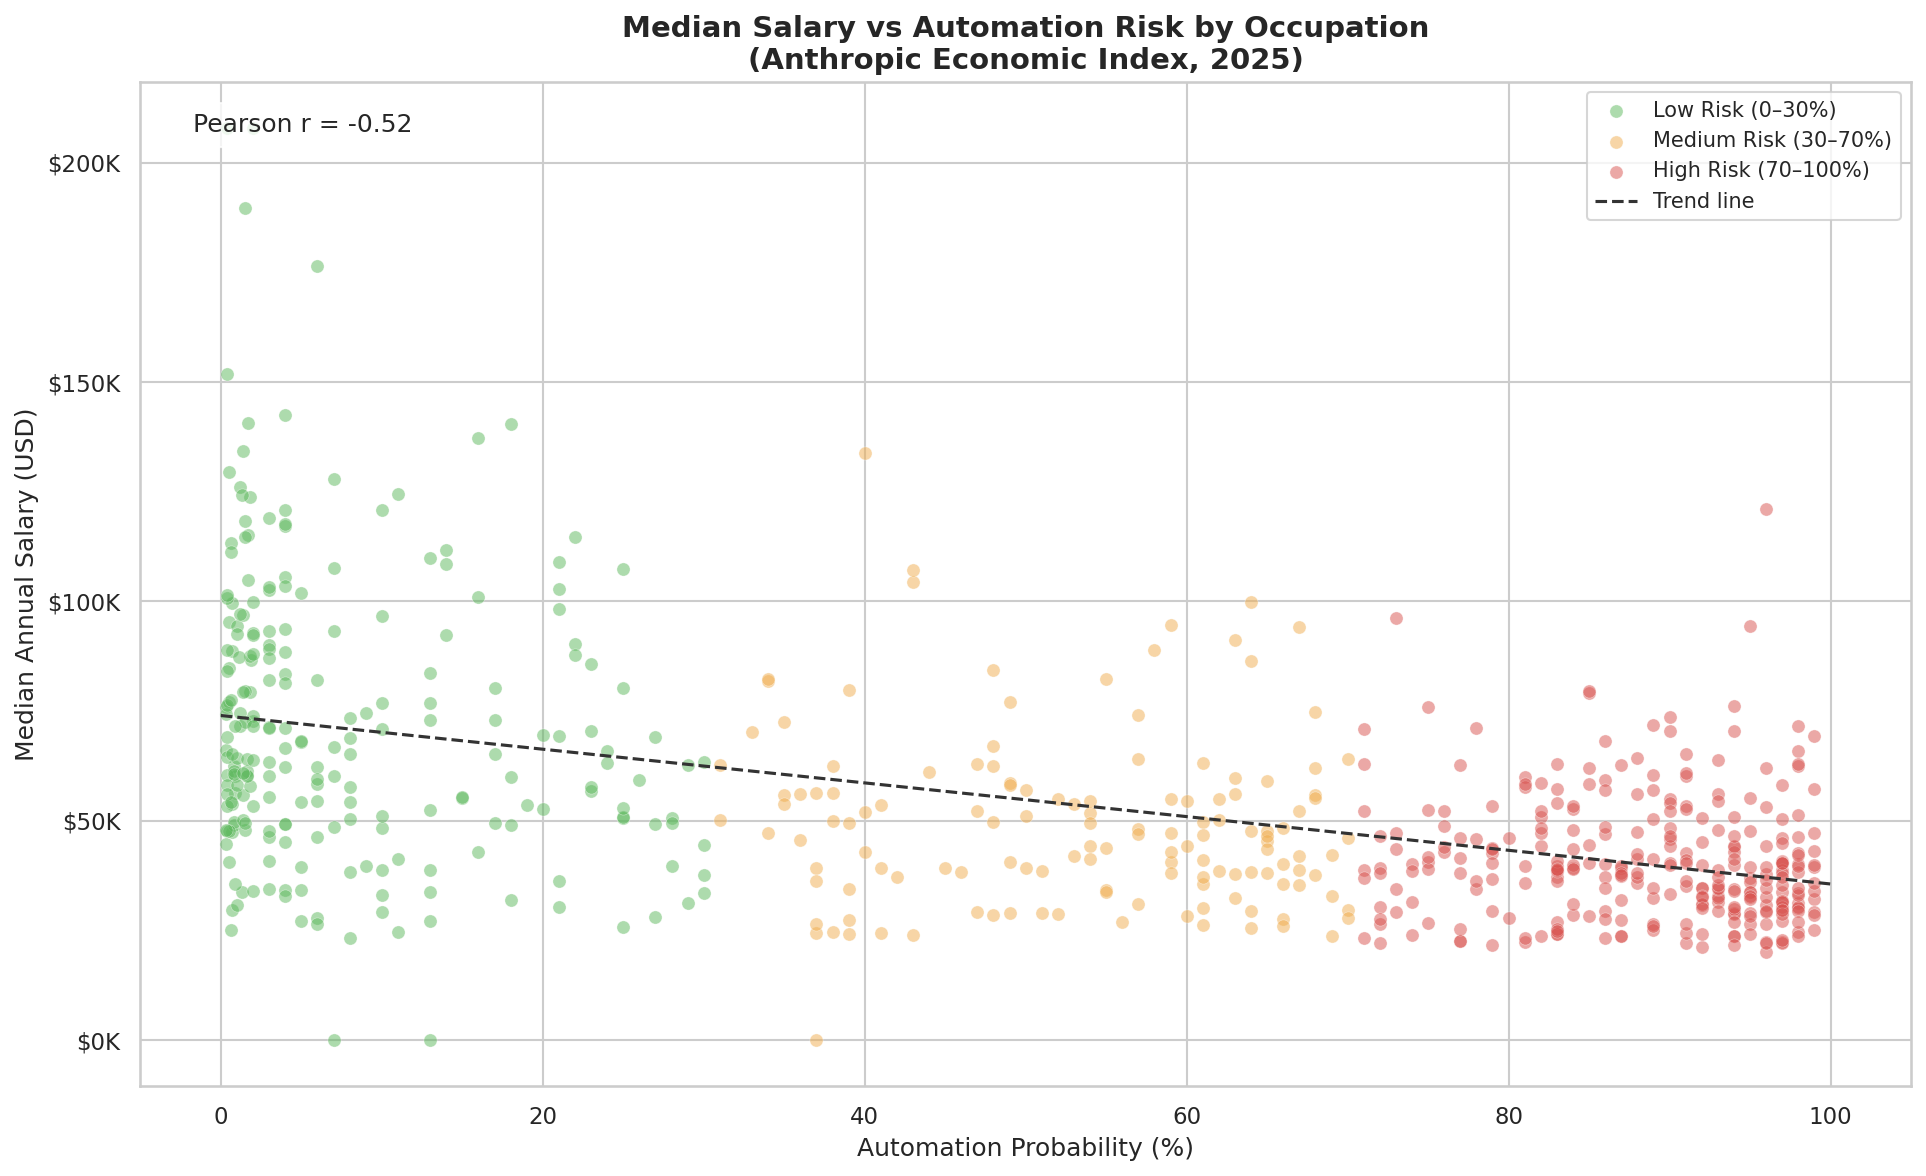

Correlation (salary vs automation risk): r = -0.517


In [3]:
import os

fig, ax = plt.subplots(figsize=(13, 8))

colors = {'Low Risk (0–30%)': '#5cb85c',
          'Medium Risk (30–70%)': '#f0ad4e',
          'High Risk (70–100%)': '#d9534f'}

for category, color in colors.items():
    subset = df_clean[df_clean['RiskCategory'] == category]
    ax.scatter(subset['ChanceAuto'], subset['MedianSalary'],
               alpha=0.5, s=40, color=color, label=category, edgecolors='white', linewidth=0.3)

# Trend line
z = np.polyfit(df_clean['ChanceAuto'], df_clean['MedianSalary'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 200)
ax.plot(x_line, p(x_line), color='#333333', linewidth=1.5,
        linestyle='--', label='Trend line', zorder=5)

# Correlation
corr = df_clean['ChanceAuto'].corr(df_clean['MedianSalary'])
ax.text(0.03, 0.95, f'Pearson r = {corr:.2f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax.set_xlabel('Automation Probability (%)', fontsize=12)
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)
ax.set_title('Median Salary vs Automation Risk by Occupation\n(Anthropic Economic Index, 2025)',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)

plt.tight_layout()

# Create the 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig4_salary_vs_automation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation (salary vs automation risk): r = {corr:.3f}")

## 2. Average Salary by Risk Category

                      Mean Salary  Median Salary  Count
RiskCategory                                           
Low Risk (0–30%)          72110.0        65320.0    235
Medium Risk (30–70%)      49533.0        46870.0    136
High Risk (70–100%)       40973.0        38860.0    295


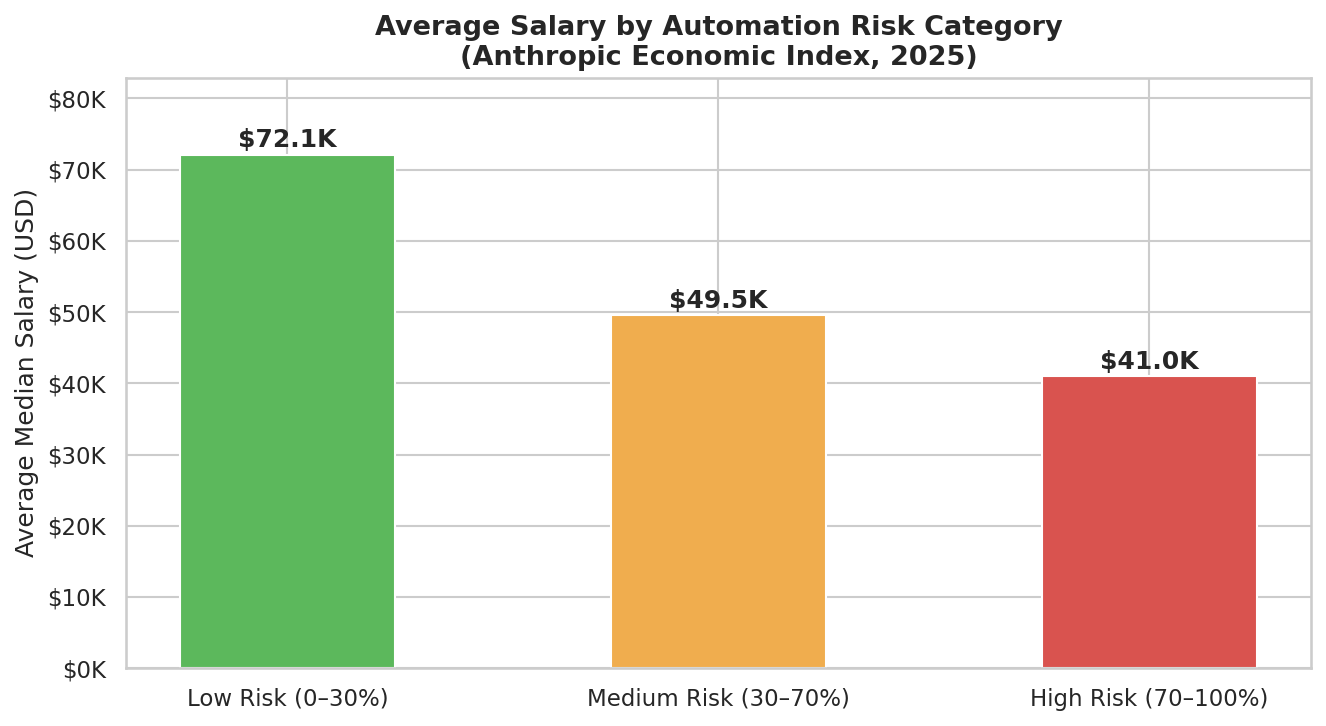

In [4]:
salary_by_risk = df_clean.groupby('RiskCategory', observed=True)['MedianSalary'].agg(
    ['mean', 'median', 'count']
).round(0)
salary_by_risk.columns = ['Mean Salary', 'Median Salary', 'Count']
print(salary_by_risk)

fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Low Risk (0–30%)', 'Medium Risk (30–70%)', 'High Risk (70–100%)']
means = [salary_by_risk.loc[c, 'Mean Salary'] for c in categories]
colors_list = ['#5cb85c', '#f0ad4e', '#d9534f']

bars = ax.bar(categories, means, color=colors_list, edgecolor='white', width=0.5)
ax.set_ylabel('Average Median Salary (USD)', fontsize=12)
ax.set_title('Average Salary by Automation Risk Category\n(Anthropic Economic Index, 2025)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1000,
            f'${val/1000:.1f}K', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, max(means) * 1.15)
plt.tight_layout()
plt.savefig('images/fig5_salary_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Which Job Families Face the Highest Automation Risk?

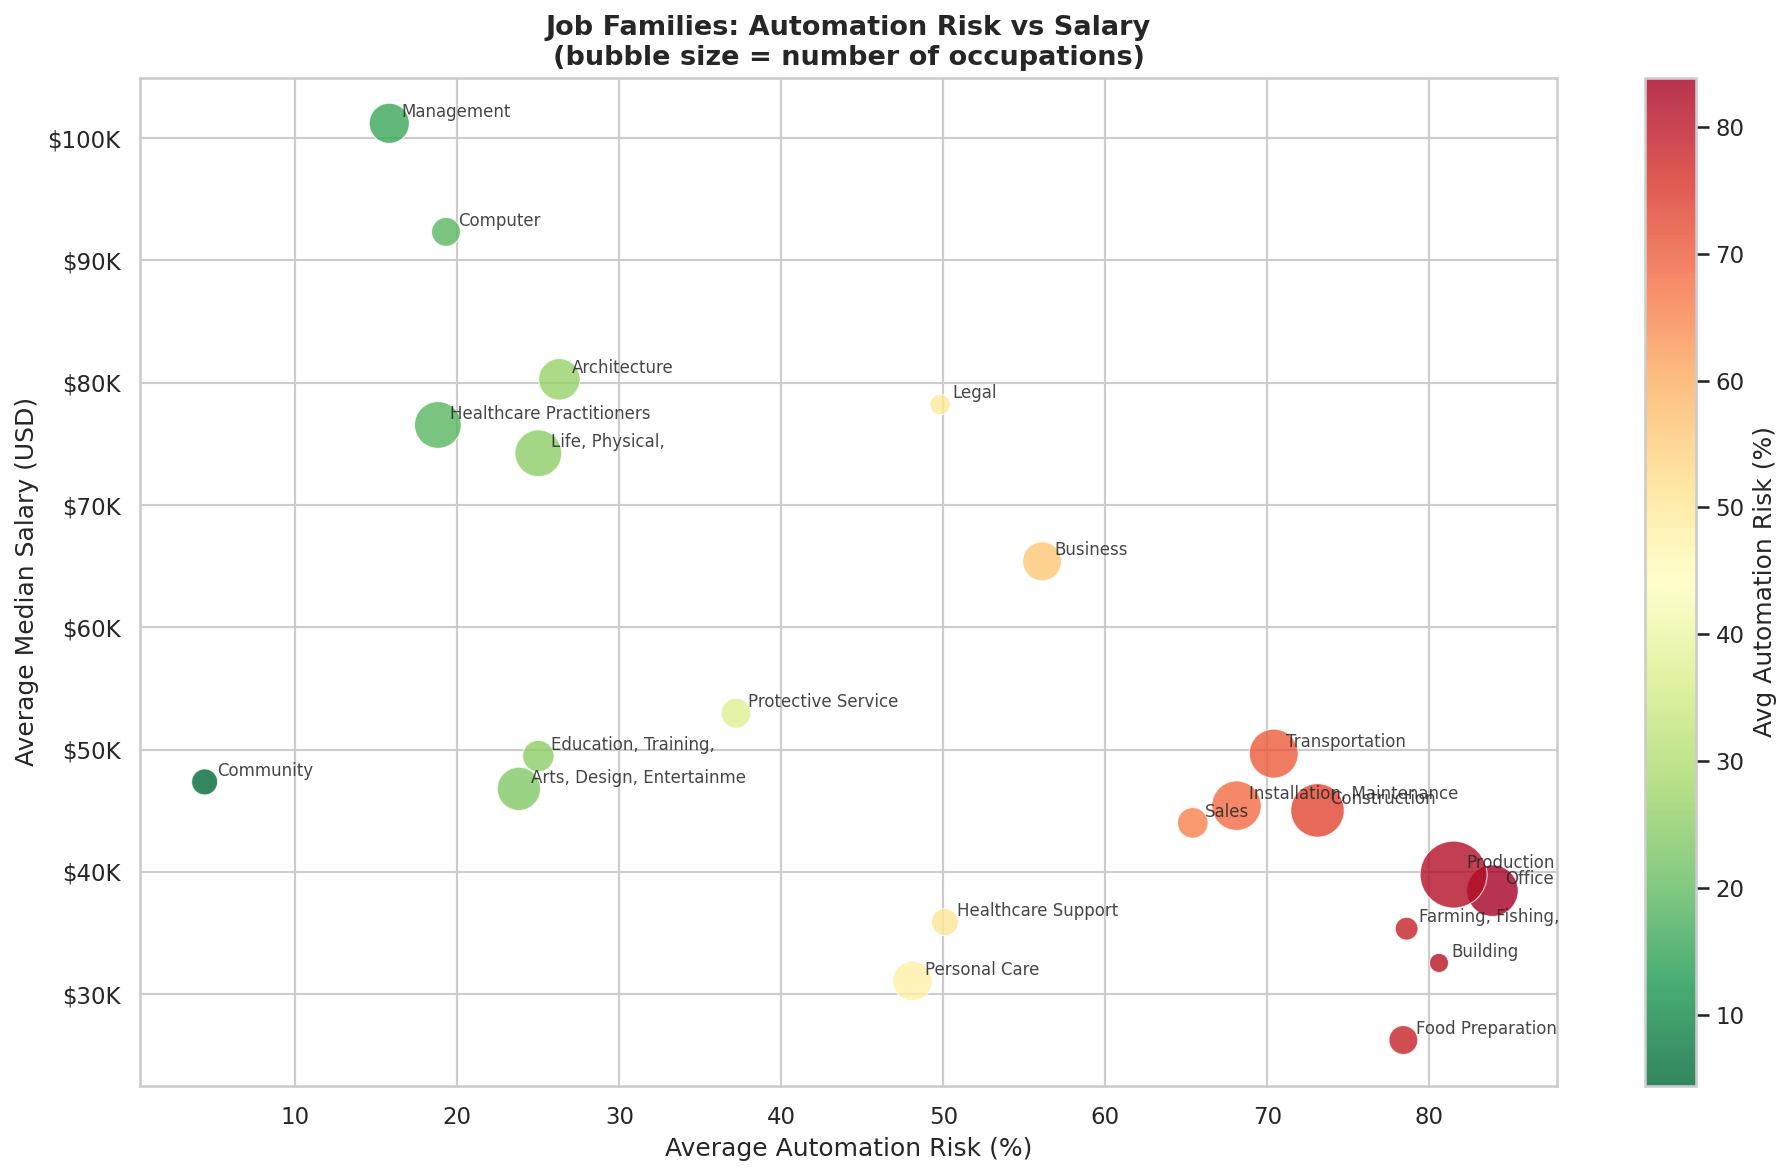


Top 5 Job Families by Automation Risk:
                                               avg_automation  avg_salary  \
JobFamily                                                                   
Office and Administrative Support                        83.9     38472.2   
Production                                               81.5     39784.7   
Building and Grounds Cleaning and Maintenance            80.6     32562.9   
Farming, Fishing, and Forestry                           78.6     35362.0   
Food Preparation and Serving Related                     78.4     26256.9   

                                               count  
JobFamily                                             
Office and Administrative Support                 51  
Production                                        86  
Building and Grounds Cleaning and Maintenance      7  
Farming, Fishing, and Forestry                    10  
Food Preparation and Serving Related              16  


In [5]:
family_stats = df_clean.groupby('JobFamily').agg(
    avg_automation=('ChanceAuto', 'mean'),
    avg_salary=('MedianSalary', 'mean'),
    count=('JobName', 'count')
).round(1).sort_values('avg_automation', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    family_stats['avg_automation'],
    family_stats['avg_salary'],
    s=family_stats['count'] * 12,
    c=family_stats['avg_automation'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)

for idx, row in family_stats.iterrows():
    short_name = idx.split(' and ')[0][:25]
    ax.annotate(short_name,
                (row['avg_automation'], row['avg_salary']),
                xytext=(6, 3), textcoords='offset points',
                fontsize=8, alpha=0.85)

plt.colorbar(scatter, ax=ax, label='Avg Automation Risk (%)')
ax.set_xlabel('Average Automation Risk (%)', fontsize=12)
ax.set_ylabel('Average Median Salary (USD)', fontsize=12)
ax.set_title('Job Families: Automation Risk vs Salary\n(bubble size = number of occupations)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/fig6_job_families_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Job Families by Automation Risk:")
print(family_stats[['avg_automation', 'avg_salary', 'count']].head())

## 4. Safe vs At-Risk: Top Paying Jobs in Each Category

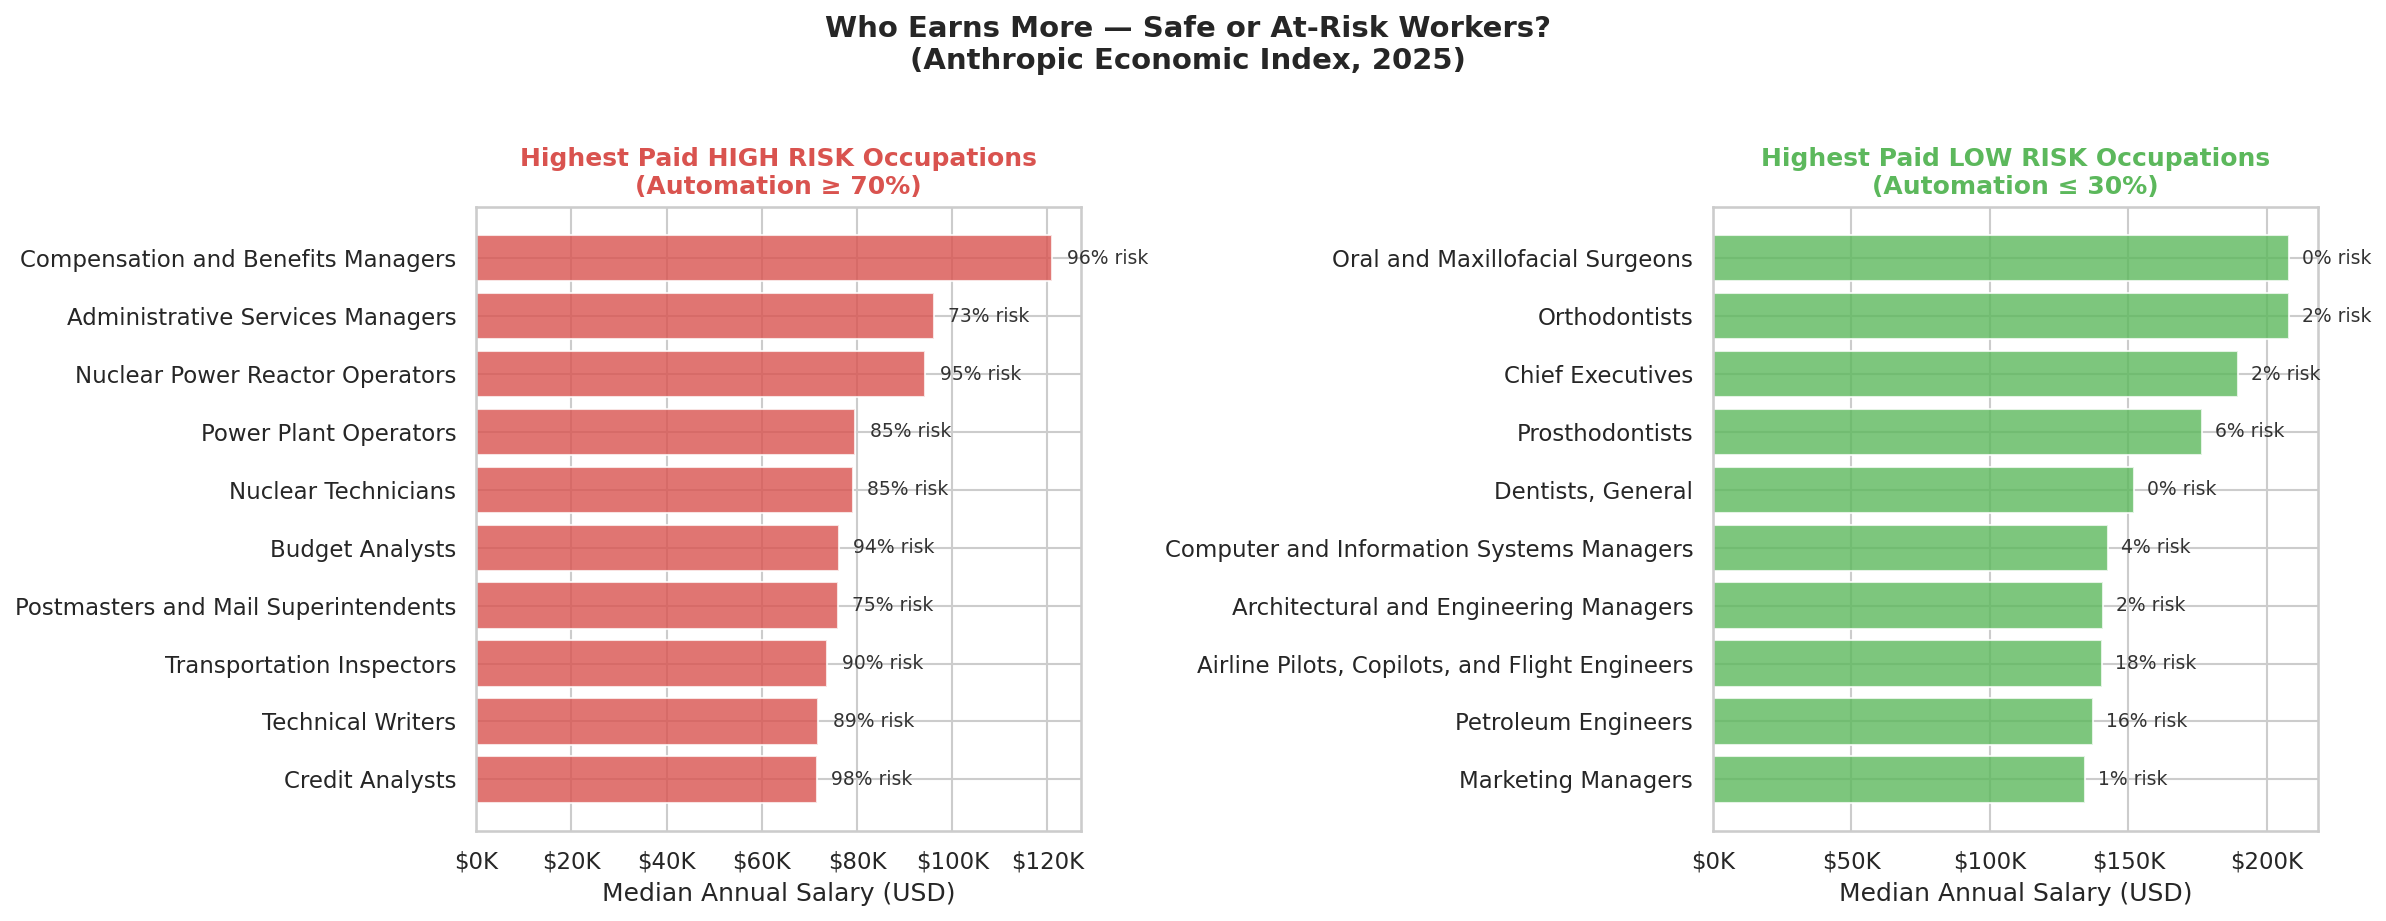

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Highest paid HIGH RISK jobs
high_risk_top = (df_clean[df_clean['ChanceAuto'] >= 70]
                 .nlargest(10, 'MedianSalary')[['JobName', 'MedianSalary', 'ChanceAuto']])

axes[0].barh(high_risk_top['JobName'], high_risk_top['MedianSalary'],
             color='#d9534f', alpha=0.8, edgecolor='white')
axes[0].set_title('Highest Paid HIGH RISK Occupations\n(Automation ≥ 70%)',
                  fontsize=12, fontweight='bold', color='#d9534f')
axes[0].set_xlabel('Median Annual Salary (USD)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].invert_yaxis()
for i, (_, row) in enumerate(high_risk_top.iterrows()):
    axes[0].text(row['MedianSalary'] + 500, i,
                 f"  {row['ChanceAuto']:.0f}% risk", va='center', fontsize=9, color='#333')

# Highest paid LOW RISK jobs
low_risk_top = (df_clean[df_clean['ChanceAuto'] <= 30]
                .nlargest(10, 'MedianSalary')[['JobName', 'MedianSalary', 'ChanceAuto']])

axes[1].barh(low_risk_top['JobName'], low_risk_top['MedianSalary'],
             color='#5cb85c', alpha=0.8, edgecolor='white')
axes[1].set_title('Highest Paid LOW RISK Occupations\n(Automation ≤ 30%)',
                  fontsize=12, fontweight='bold', color='#5cb85c')
axes[1].set_xlabel('Median Annual Salary (USD)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].invert_yaxis()
for i, (_, row) in enumerate(low_risk_top.iterrows()):
    axes[1].text(row['MedianSalary'] + 500, i,
                 f"  {row['ChanceAuto']:.0f}% risk", va='center', fontsize=9, color='#333')

plt.suptitle('Who Earns More — Safe or At-Risk Workers?\n(Anthropic Economic Index, 2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/fig7_salary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Findings

In [7]:
high_risk = df_clean[df_clean['ChanceAuto'] >= 70]
low_risk  = df_clean[df_clean['ChanceAuto'] <= 30]
corr = df_clean['ChanceAuto'].corr(df_clean['MedianSalary'])

print("=" * 55)
print("KEY FINDINGS — Salary vs Automation Risk")
print("=" * 55)
print(f"\n1. CORRELATION")
print(f"   Pearson r = {corr:.3f} → {'negative' if corr < 0 else 'positive'} relationship")
print(f"   Higher automation risk = lower average salary")

print(f"\n2. SALARY GAP")
diff = low_risk['MedianSalary'].mean() - high_risk['MedianSalary'].mean()
print(f"   Low-risk jobs earn on avg:  ${low_risk['MedianSalary'].mean():,.0f}/yr")
print(f"   High-risk jobs earn on avg: ${high_risk['MedianSalary'].mean():,.0f}/yr")
print(f"   Difference: ${diff:,.0f}/yr ({diff/high_risk['MedianSalary'].mean()*100:.0f}% more for safe jobs)")

print(f"\n3. MOST VULNERABLE SECTOR")
most_at_risk = family_stats['avg_automation'].idxmax()
print(f"   {most_at_risk}")
print(f"   Avg automation risk: {family_stats.loc[most_at_risk, 'avg_automation']:.1f}%")

print(f"\n4. SAFEST SECTOR")
safest = family_stats['avg_automation'].idxmin()
print(f"   {safest}")
print(f"   Avg automation risk: {family_stats.loc[safest, 'avg_automation']:.1f}%")

KEY FINDINGS — Salary vs Automation Risk

1. CORRELATION
   Pearson r = -0.517 → negative relationship
   Higher automation risk = lower average salary

2. SALARY GAP
   Low-risk jobs earn on avg:  $72,110/yr
   High-risk jobs earn on avg: $40,986/yr
   Difference: $31,124/yr (76% more for safe jobs)

3. MOST VULNERABLE SECTOR
   Office and Administrative Support
   Avg automation risk: 83.9%

4. SAFEST SECTOR
   Community and Social Service
   Avg automation risk: 4.4%
